In [1]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from statsmodels.tsa.seasonal import seasonal_decompose 
  
# Read the AirPassengers dataset 
sea_passanger = pd.read_csv('2020-2025.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  


C:\Users\athiy\AppData\Local\Temp\ipykernel_21476\75316304.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sea_passanger = pd.read_csv('2020-2025.csv',


In [2]:
sea_passanger

,Penumpang
Tahun,
2020-01-01,18821
2020-02-01,14667
2020-03-01,17103
2020-04-01,5024
2020-05-01,2267
...,...
2024-11-01,23251
2024-12-01,25349
2025-01-01,18614


In [69]:
sea_passanger.describe()

,Penumpang
count,63.000000
mean,22934.492063
std,12850.799544
min,2267.000000
25%,13731.000000
50%,19754.000000
75%,32522.000000
max,61649.000000


In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(sea_passanger['Penumpang'])

ADF Statistic: -0.6640931527930876
p-value: 0.8558323273693839
Non-Stationary


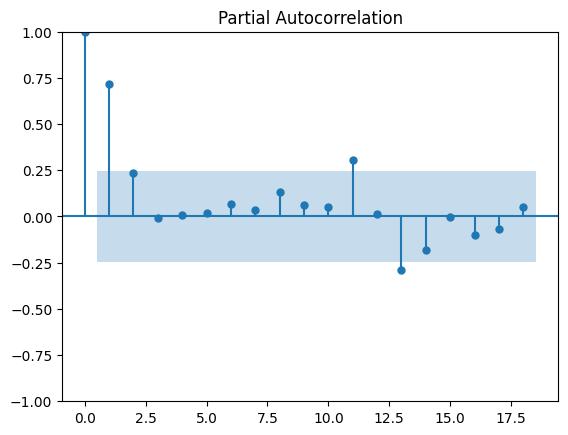

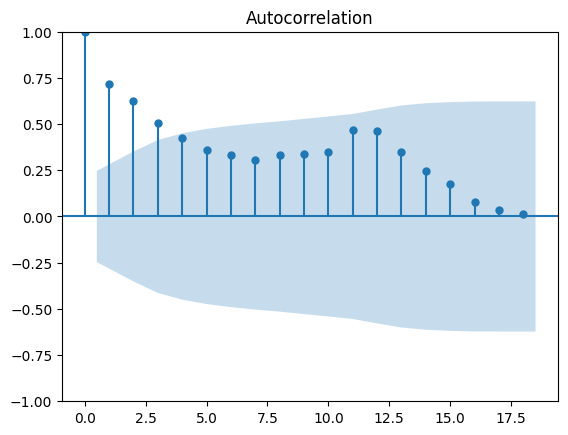

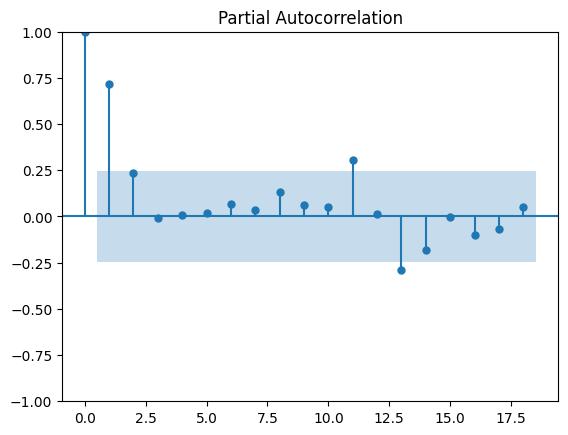

In [71]:
plot_acf(sea_passanger['Penumpang'])

plot_pacf(sea_passanger['Penumpang'])

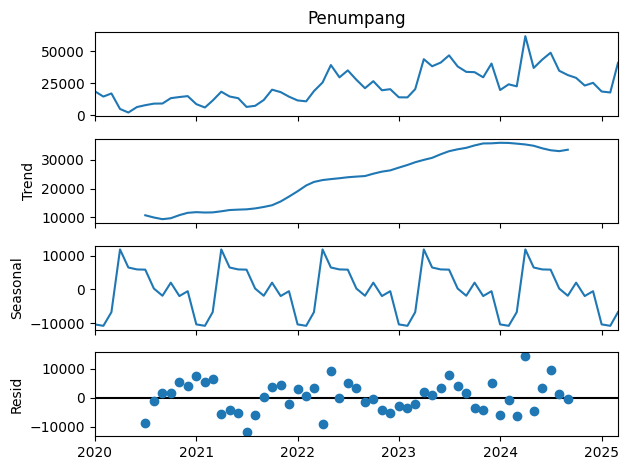

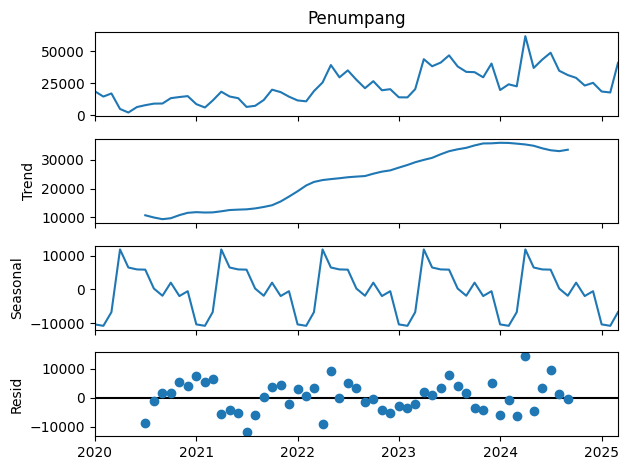

In [72]:
# ETS Decomposition 
result = seasonal_decompose(sea_passanger['Penumpang'],  
                            model ='additive') 
  
# ETS plot  
result.plot() 


In [73]:
# Split into train and test sets
train_size = int(len(sea_passanger) * 0.8)
train= sea_passanger[:train_size]
test = sea_passanger[train_size:]


In [94]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

ucm_model = UnobservedComponents(train,  level=True, seasonal=12, stochastic_seasonal=True, cycle=True,  stochastic_cycle=True)

ucm_fit = ucm_model.fit(disp=False)

# Print model summary
print(ucm_fit.summary())

                            Unobserved Components Results                            
Dep. Variable:                     Penumpang   No. Observations:                   50
Model:                       fixed intercept   Log Likelihood                -374.007
                   + stochastic seasonal(12)   AIC                            754.014
                          + stochastic cycle   BIC                            758.765
Date:                       Wed, 18 Jun 2025   HQIC                           755.672
Time:                               11:46:37                                         
Sample:                           01-01-2020                                         
                                - 02-01-2024                                         
Covariance Type:                         opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\statespace\structural.py:1030: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-unconstrained[offset]))


In [95]:
forecast_ucm = ucm_fit.forecast(steps=13)


In [96]:
forecast_ucm

2024-03-01    21085.821499
2024-04-01    29424.423363
2024-05-01    23654.297456
2024-06-01    21143.285559
2024-07-01    24761.474188
2024-08-01    19438.052034
2024-09-01    18036.667756
2024-10-01    21351.238427
2024-11-01    17115.704920
2024-12-01    25143.875964
2025-01-01    12123.911109
2025-02-01    13909.845791
2025-03-01    10465.160362
Freq: MS, Name: predicted_mean, dtype: float64

<Axes: >

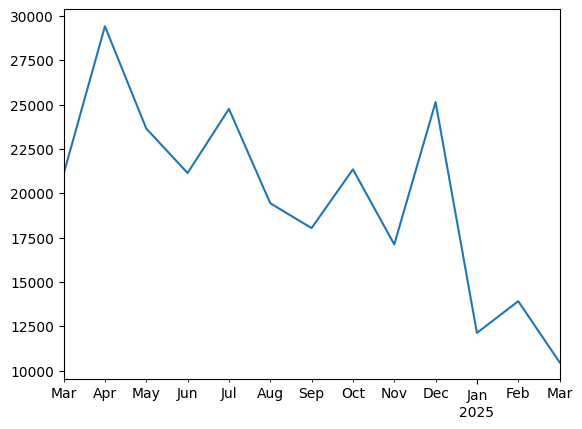

In [97]:
forecast_ucm.plot()

In [98]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse 


# Calculate mean squared error 
MSE = mean_squared_error(test, forecast_ucm) 

# Calculate mean absolute error 
MAE = mean_absolute_error(test, forecast_ucm) 

# R squared
R2 = r2_score(test, forecast_ucm) 

# MAPE
MAPE = mean_absolute_percentage_error(test, forecast_ucm)


C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)`

In [99]:
print(f'''

MSE   : { round(MSE, 3) }

MAE   : { round(MAE, 3) }

R2    : { round(R2, 3) } 

MAPE   : { round(MAPE, 3) }
MAPE % : { round(MAPE*100, 3) } %
''')




MSE   : 291300878.838

MAE   : 13621.788

R2    : -0.921 

MAPE   : 0.36
MAPE % : 35.973 %



In [8]:
from datetime import datetime, timedelta

sd = datetime(2009, 1, 1)
ed = datetime(2012, 12, 1)

d = []

while sd <= ed:
    d.append(sd.strftime("%d/%m/%Y"))
    sd += timedelta(days=30)

print(d)

['01/01/2009', '31/01/2009', '02/03/2009', '01/04/2009', '01/05/2009', '31/05/2009', '30/06/2009', '30/07/2009', '29/08/2009', '28/09/2009', '28/10/2009', '27/11/2009', '27/12/2009', '26/01/2010', '25/02/2010', '27/03/2010', '26/04/2010', '26/05/2010', '25/06/2010', '25/07/2010', '24/08/2010', '23/09/2010', '23/10/2010', '22/11/2010', '22/12/2010', '21/01/2011', '20/02/2011', '22/03/2011', '21/04/2011', '21/05/2011', '20/06/2011', '20/07/2011', '19/08/2011', '18/09/2011', '18/10/2011', '17/11/2011', '17/12/2011', '16/01/2012', '15/02/2012', '16/03/2012', '15/04/2012', '15/05/2012', '14/06/2012', '14/07/2012', '13/08/2012', '12/09/2012', '12/10/2012', '11/11/2012']


('2012-02', '2020-03')
